# Data Decontamination — Phase 3 Analysis

Full analysis pipeline: dataset construction → LLM-as-judge → accuracy breakdown → DiD → recitation rates → CoT analysis.


## 0. Setup

In [ ]:
import json
import re
import string
import asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import defaultdict
from scipy import stats
from openai import AsyncOpenAI

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'contaminated': '#e07b54', 'clean': '#5b8db8'}

API_KEY = "insert-api-key-here"

FILES = {
    'OpenThoughts': {
        'cont': 'prev_runs/did_traces_openthoughts_cont.jsonl',
        'clean': 'did_traces_openthoughts_clean.jsonl',
        'combined': 'did_traces_openthoughts_combined.jsonl',
    },
    'Tulu': {
        'cont': 'prev_runs/did_traces_tulu_cont.jsonl',
        'clean': 'did_traces_tulu_clean.jsonl',
        'combined': 'did_traces_tulu_combined.jsonl',
    },
}

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

print('Setup complete.')

Setup complete.


## 1. Dataset Construction

Combine only `split == 'contaminated'` rows from `prev_runs/` with all clean samples.

In [2]:
for label, paths in FILES.items():
    records = []
    with open(paths['cont']) as f:
        for line in f:
            r = json.loads(line.strip())
            if r.get('split') == 'contaminated':
                records.append(r)
    with open(paths['clean']) as f:
        for line in f:
            records.append(json.loads(line.strip()))
    with open(paths['combined'], 'w') as f:
        for r in records:
            f.write(json.dumps(r) + '\n')
    cont_n = sum(1 for r in records if r['split'] == 'contaminated')
    clean_n = sum(1 for r in records if r['split'] == 'clean')
    print(f'{label}: {cont_n} contaminated + {clean_n} clean = {len(records)} total')

OpenThoughts: 72 contaminated + 72 clean = 144 total
Tulu: 96 contaminated + 96 clean = 192 total


## 2. Null Final Answer Analysis

       Model       Source  Total  Nulls
OpenThoughts contaminated     72     18
OpenThoughts        clean     72     14
        Tulu contaminated     96      9
        Tulu        clean     96      2


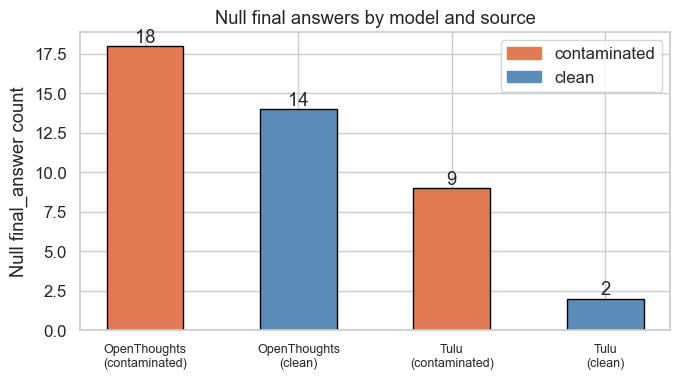

In [3]:
null_summary = []
for label, paths in FILES.items():
    for src, path in [('contaminated', paths['cont']), ('clean', paths['clean'])]:
        if src == 'contaminated':
            records = [r for r in load_jsonl(path) if r.get('split') == 'contaminated']
        else:
            records = load_jsonl(path)
        nulls = sum(1 for r in records if r.get('final_answer') is None)
        null_summary.append({'Model': label, 'Source': src, 'Total': len(records), 'Nulls': nulls})

null_df = pd.DataFrame(null_summary)
print(null_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(null_df))
bars = ax.bar(x, null_df['Nulls'], color=[PALETTE[s] for s in null_df['Source']], edgecolor='black', width=0.5)
ax.bar_label(bars, fmt='%d')
ax.set_xticks(x)
ax.set_xticklabels([f"{r.Model}\n({r.Source})" for r in null_df.itertuples()], fontsize=9)
ax.set_ylabel('Null final_answer count')
ax.set_title('Null final answers by model and source')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in PALETTE.items()])
plt.tight_layout()
plt.savefig('fig_null_counts.png', dpi=150)
plt.show()

## 3. LLM-as-Judge Accuracy Labeling

Replace exact-match `correct` with an LLM judge that handles mathematically equivalent forms.

In [4]:
JUDGE_PROMPT = """You are a math answer grader. Decide if the predicted answer is mathematically equivalent to the ground truth.

Rules:
- Treat equivalent forms as correct: fractions vs decimals, different radical forms, reordered terms, etc.
- A null, blank, or "I don't know" predicted answer is INCORRECT.
- Respond with exactly one word: CORRECT or INCORRECT."""

client = AsyncOpenAI(api_key=API_KEY)
sem = asyncio.Semaphore(20)

async def judge(final_answer, ground_truth):
    if final_answer is None:
        return False
    async with sem:
        resp = await client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[
                {'role': 'system', 'content': JUDGE_PROMPT},
                {'role': 'user', 'content': f'Ground truth: {ground_truth}\nPredicted: {final_answer}'},
            ],
            temperature=0, max_tokens=5,
        )
    return resp.choices[0].message.content.strip().upper() == 'CORRECT'

async def label_file(path):
    records = load_jsonl(path)
    results = await asyncio.gather(*[judge(r.get('final_answer'), r.get('ground_truth')) for r in records])
    changed = sum(1 for r, new in zip(records, results) if r.get('correct') != new)
    for r, new in zip(records, results):
        r['llm_correct'] = new
    with open(path, 'w') as f:
        for r in records:
            f.write(json.dumps(r) + '\n')
    exact = sum(1 for r in records if r.get('correct'))
    llm   = sum(results)
    print(f'{path}: exact={exact}, llm={llm}, changed={changed}')

async def run_all():
    for paths in FILES.values():
        await label_file(paths['combined'])

await run_all()

did_traces_openthoughts_combined.jsonl: exact=64, llm=89, changed=25
did_traces_tulu_combined.jsonl: exact=45, llm=50, changed=5


## 4. Accuracy Breakdown: Model × Split × Perturbation Type

In [5]:
rows = []
for label, paths in FILES.items():
    for r in load_jsonl(paths['combined']):
        rows.append({
            'model': label,
            'split': r['split'],
            'perturbation_type': r['perturbation_type'],
            'level': r.get('level'),
            'llm_correct': r.get('llm_correct', False),
        })
df = pd.DataFrame(rows)
df['llm_correct'] = df['llm_correct'].astype(float)

summary = (df.groupby(['model', 'split', 'perturbation_type'])
             .agg(n=('llm_correct', 'count'),
                  accuracy=('llm_correct', 'mean'),
                  avg_level=('level', lambda x: pd.to_numeric(x, errors='coerce').mean()))
             .reset_index())
summary['correct'] = (summary['accuracy'] * summary['n']).round().astype(int)
print(summary[['model','split','perturbation_type','n','correct','accuracy','avg_level']].to_string(index=False))

       model        split perturbation_type  n  correct  accuracy  avg_level
OpenThoughts        clean       number_swap 24        8  0.333333    3.50000
OpenThoughts        clean          original 24       19  0.791667    3.50000
OpenThoughts        clean     surface_noise 24       19  0.791667    3.50000
OpenThoughts contaminated       number_swap 24        9  0.375000    3.50000
OpenThoughts contaminated          original 24       18  0.750000    3.50000
OpenThoughts contaminated     surface_noise 24       16  0.666667    3.50000
        Tulu        clean       number_swap 32        8  0.250000    3.28125
        Tulu        clean          original 32        8  0.250000    3.28125
        Tulu        clean     surface_noise 32        6  0.187500    3.28125
        Tulu contaminated       number_swap 32        9  0.281250    3.28125
        Tulu contaminated          original 32       10  0.312500    3.28125
        Tulu contaminated     surface_noise 32        9  0.281250    3.28125

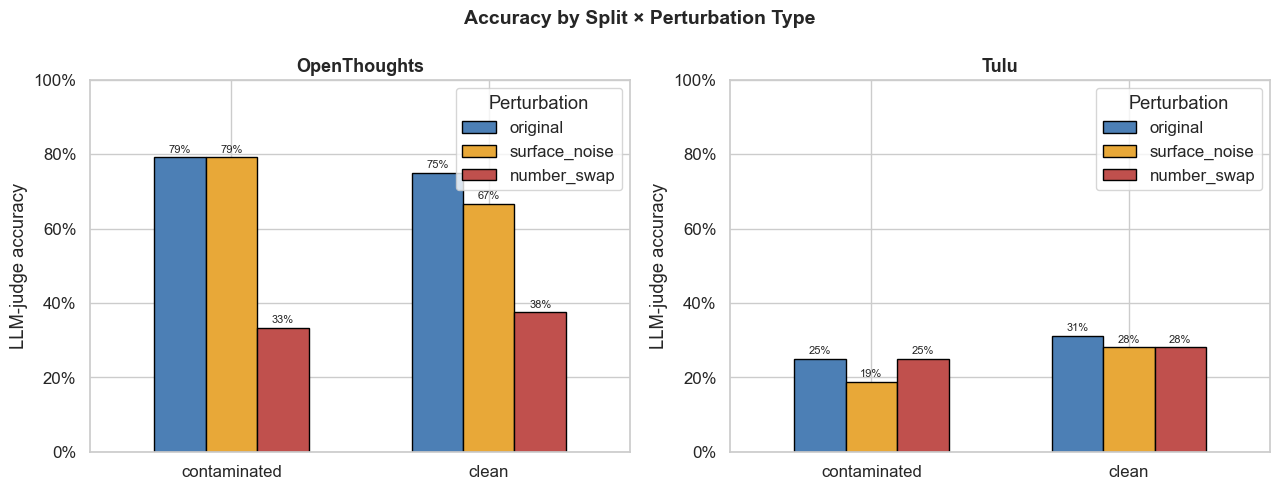

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
ptype_order = ['original', 'surface_noise', 'number_swap']

for ax, (label, paths) in zip(axes, FILES.items()):
    sub = summary[summary['model'] == label]
    pivot = sub.pivot_table(index='split', columns='perturbation_type', values='accuracy')[ptype_order]
    pivot.plot(kind='bar', ax=ax, color=['#4c7fb5', '#e8a838', '#c0504d'],
               edgecolor='black', width=0.6)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('LLM-judge accuracy')
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticklabels(['contaminated', 'clean'], rotation=0)
    ax.legend(title='Perturbation', loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{x:.0%}', fontsize=8, padding=2)

fig.suptitle('Accuracy by Split × Perturbation Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_accuracy_breakdown.png', dpi=150)
plt.show()

## 5. DiD (Difference-in-Differences) with Bootstrap CI + Welch's t-test

In [7]:
def compute_did(records, perturb_type, n_bootstrap=10_000, seed=42):
    pairs = [r for r in records if r['perturbation_type'] in ('original', perturb_type)]
    by_problem = defaultdict(dict)
    for r in pairs:
        by_problem[(r['math500_id'], r['split'])][r['perturbation_type']] = int(r.get('llm_correct') or 0)
    delta_C, delta_N = [], []
    for (mid, split), ptypes in by_problem.items():
        if 'original' not in ptypes or perturb_type not in ptypes:
            continue
        delta = ptypes['original'] - ptypes[perturb_type]
        (delta_C if split == 'contaminated' else delta_N).append(delta)
    delta_C, delta_N = np.array(delta_C), np.array(delta_N)
    if not len(delta_C) or not len(delta_N):
        return None
    did = delta_C.mean() - delta_N.mean()
    rng = np.random.default_rng(seed)
    boots = np.array([
        rng.choice(delta_C, len(delta_C), replace=True).mean() -
        rng.choice(delta_N, len(delta_N), replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    ci_low, ci_high = np.percentile(boots, [2.5, 97.5])
    t_stat, p_val = stats.ttest_ind(delta_C, delta_N, equal_var=False)
    return dict(n_C=len(delta_C), n_N=len(delta_N), delta_C=delta_C.mean(),
                delta_N=delta_N.mean(), did=did, ci_low=ci_low, ci_high=ci_high,
                t=t_stat, p=p_val)

N_TOTAL = 500
did_rows = []
for label, paths in FILES.items():
    records = load_jsonl(paths['combined'])
    n_contam = len(set(r['math500_id'] for r in records if r['split'] == 'contaminated'))
    for ptype in ['number_swap', 'surface_noise']:
        r = compute_did(records, ptype)
        if r:
            did_rows.append({'Model': label, 'Perturbation': ptype, 'N_contam': n_contam, **r})

did_df = pd.DataFrame(did_rows)
did_df['inflation'] = did_df['N_contam'] * did_df['did'] / N_TOTAL
did_df['inflation_lo'] = did_df['N_contam'] * did_df['ci_low'] / N_TOTAL
did_df['inflation_hi'] = did_df['N_contam'] * did_df['ci_high'] / N_TOTAL
print(did_df[['Model','Perturbation','n_C','n_N','delta_C','delta_N','did','ci_low','ci_high','t','p','inflation']].to_string(index=False))

       Model  Perturbation  n_C  n_N  delta_C  delta_N       did   ci_low  ci_high         t        p  inflation
OpenThoughts   number_swap   24   24 0.375000 0.458333 -0.083333 -0.37500 0.208333 -0.575270 0.567915     -0.004
OpenThoughts surface_noise   24   24 0.083333 0.000000  0.083333 -0.12500 0.333333  0.699544 0.487736      0.004
        Tulu   number_swap   32   32 0.031250 0.000000  0.031250 -0.21875 0.281250  0.238936 0.811946      0.002
        Tulu surface_noise   32   32 0.031250 0.062500 -0.031250 -0.28125 0.218750 -0.255467 0.799212     -0.002


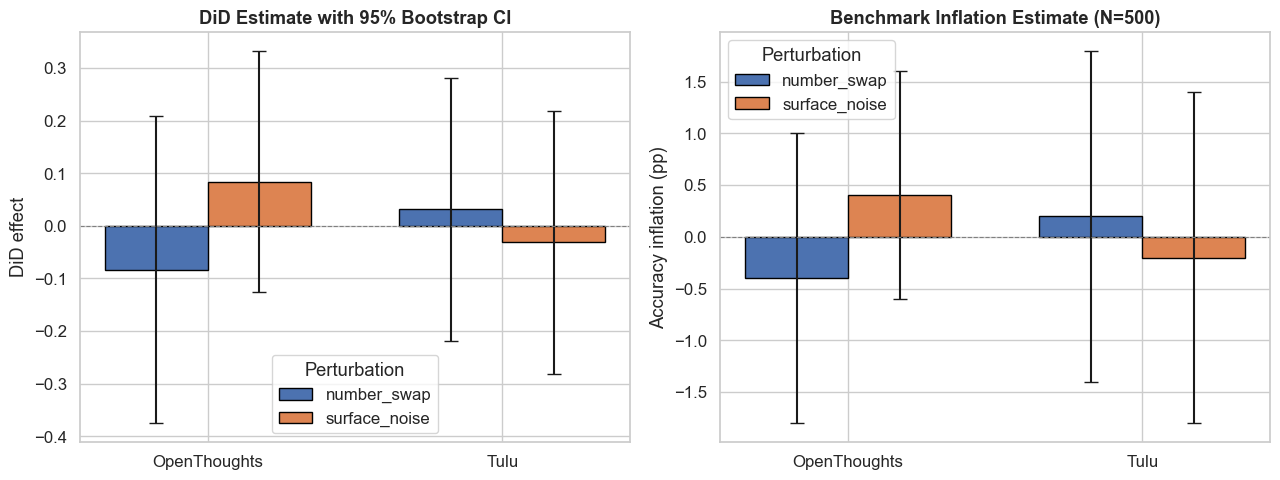

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) DiD point estimates with 95% CI
ax = axes[0]
models = did_df['Model'].unique()
x = np.arange(len(models))
width = 0.35
for i, ptype in enumerate(['number_swap', 'surface_noise']):
    sub = did_df[did_df['Perturbation'] == ptype].set_index('Model').reindex(models)
    offset = (i - 0.5) * width
    ax.bar(x + offset, sub['did'], width,
           label=ptype, edgecolor='black',
           yerr=[sub['did'] - sub['ci_low'], sub['ci_high'] - sub['did']],
           capsize=5, error_kw={'linewidth': 1.5})
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('DiD effect')
ax.set_title('DiD Estimate with 95% Bootstrap CI', fontweight='bold')
ax.legend(title='Perturbation')

# (b) Benchmark inflation
ax = axes[1]
for i, ptype in enumerate(['number_swap', 'surface_noise']):
    sub = did_df[did_df['Perturbation'] == ptype].set_index('Model').reindex(models)
    offset = (i - 0.5) * width
    ax.bar(x + offset, sub['inflation'] * 100, width,
           label=ptype, edgecolor='black',
           yerr=[(sub['inflation'] - sub['inflation_lo']) * 100,
                 (sub['inflation_hi'] - sub['inflation']) * 100],
           capsize=5, error_kw={'linewidth': 1.5})
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy inflation (pp)')
ax.set_title('Benchmark Inflation Estimate (N=500)', fontweight='bold')
ax.legend(title='Perturbation')

plt.tight_layout()
plt.savefig('fig_did_inflation.png', dpi=150)
plt.show()

## 6. Recitation Rate Analysis

For `number_swap` problems: does the model output the *original* benchmark answer instead of the perturbed one?

In [9]:
def normalize(s):
    return str(s).strip().lower() if s is not None else None

def compute_recitation(records):
    orig_gt = {(r['math500_id'], r['split']): normalize(r['ground_truth'])
               for r in records if r['perturbation_type'] == 'original'}
    ns_rows = [r for r in records if r['perturbation_type'] == 'number_swap']
    results = defaultdict(lambda: {'recited':0,'correct':0,'neither':0,'null':0,'ambiguous':0,'total':0})
    for r in ns_rows:
        split = r['split']
        orig_ans = orig_gt.get((r['math500_id'], split))
        pert_ans = normalize(r['ground_truth'])
        final    = normalize(r.get('final_answer'))
        results[split]['total'] += 1
        if final is None:            results[split]['null'] += 1
        elif orig_ans == pert_ans:   results[split]['ambiguous'] += 1
        elif final == orig_ans:      results[split]['recited'] += 1
        elif final == pert_ans:      results[split]['correct'] += 1
        else:                        results[split]['neither'] += 1
    return results

rec_rows = []
for label, paths in FILES.items():
    res = compute_recitation(load_jsonl(paths['combined']))
    for split, g in res.items():
        evaluable = g['total'] - g['ambiguous'] - g['null']
        rate = g['recited'] / evaluable if evaluable else float('nan')
        rec_rows.append({'Model': label, 'Split': split, **g, 'rate': rate})

rec_df = pd.DataFrame(rec_rows)
print(rec_df[['Model','Split','total','ambiguous','recited','correct','neither','null','rate']].to_string(index=False))

       Model        Split  total  ambiguous  recited  correct  neither  null     rate
OpenThoughts contaminated     24          1        0        6        8     9 0.000000
OpenThoughts        clean     24          1        1        3       14     5 0.055556
        Tulu contaminated     32          6        0        6       18     2 0.000000
        Tulu        clean     32          4        0        5       23     0 0.000000


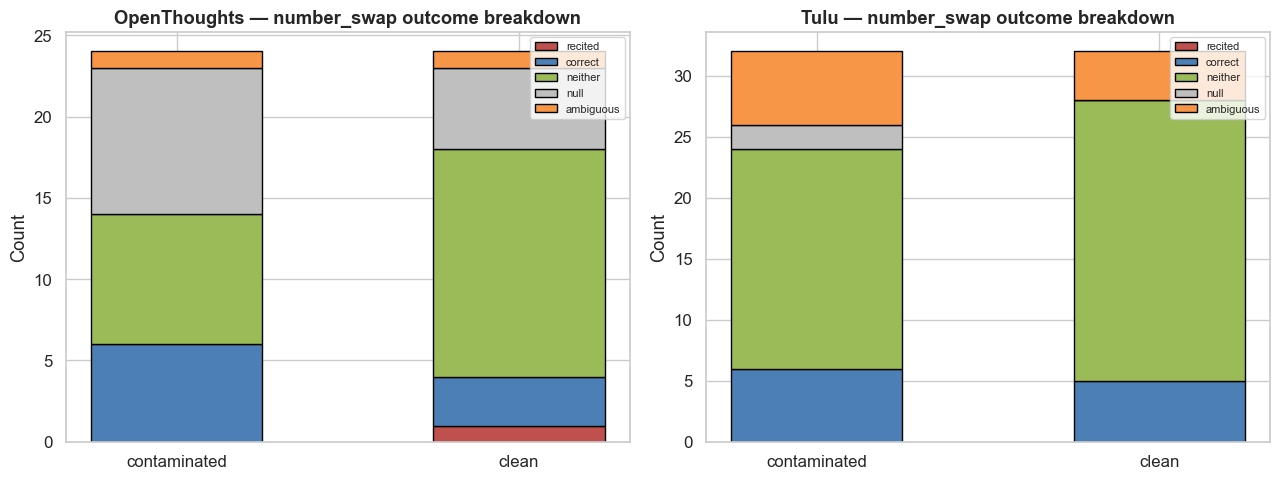

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, paths) in zip(axes, FILES.items()):
    sub = rec_df[rec_df['Model'] == label].set_index('Split')
    cats = ['recited', 'correct', 'neither', 'null', 'ambiguous']
    colors = ['#c0504d', '#4c7fb5', '#9bbb59', '#bfbfbf', '#f79646']
    bottom = np.zeros(2)
    splits = ['contaminated', 'clean']
    x = np.arange(len(splits))
    for cat, color in zip(cats, colors):
        vals = [sub.loc[s, cat] if s in sub.index else 0 for s in splits]
        ax.bar(x, vals, bottom=bottom, label=cat, color=color, edgecolor='black', width=0.5)
        bottom += np.array(vals)
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_title(f'{label} — number_swap outcome breakdown', fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('fig_recitation.png', dpi=150)
plt.show()

## 7. Null Rate Breakdown by Split × Perturbation

In [11]:
null_rows = []
for label, paths in FILES.items():
    for r in load_jsonl(paths['combined']):
        null_rows.append({'Model': label, 'split': r['split'],
                          'perturbation_type': r['perturbation_type'],
                          'is_null': r.get('final_answer') is None})
null_rate_df = (pd.DataFrame(null_rows)
                .groupby(['Model','split','perturbation_type'])['is_null']
                .agg(['sum','count']).reset_index()
                .rename(columns={'sum':'nulls','count':'total'}))
null_rate_df['null_pct'] = null_rate_df['nulls'] / null_rate_df['total'] * 100
print(null_rate_df.to_string(index=False))

       Model        split perturbation_type  nulls  total  null_pct
OpenThoughts        clean       number_swap      5     24 20.833333
OpenThoughts        clean          original      4     24 16.666667
OpenThoughts        clean     surface_noise      5     24 20.833333
OpenThoughts contaminated       number_swap      9     24 37.500000
OpenThoughts contaminated          original      4     24 16.666667
OpenThoughts contaminated     surface_noise      5     24 20.833333
        Tulu        clean       number_swap      0     32  0.000000
        Tulu        clean          original      1     32  3.125000
        Tulu        clean     surface_noise      1     32  3.125000
        Tulu contaminated       number_swap      2     32  6.250000
        Tulu contaminated          original      5     32 15.625000
        Tulu contaminated     surface_noise      2     32  6.250000


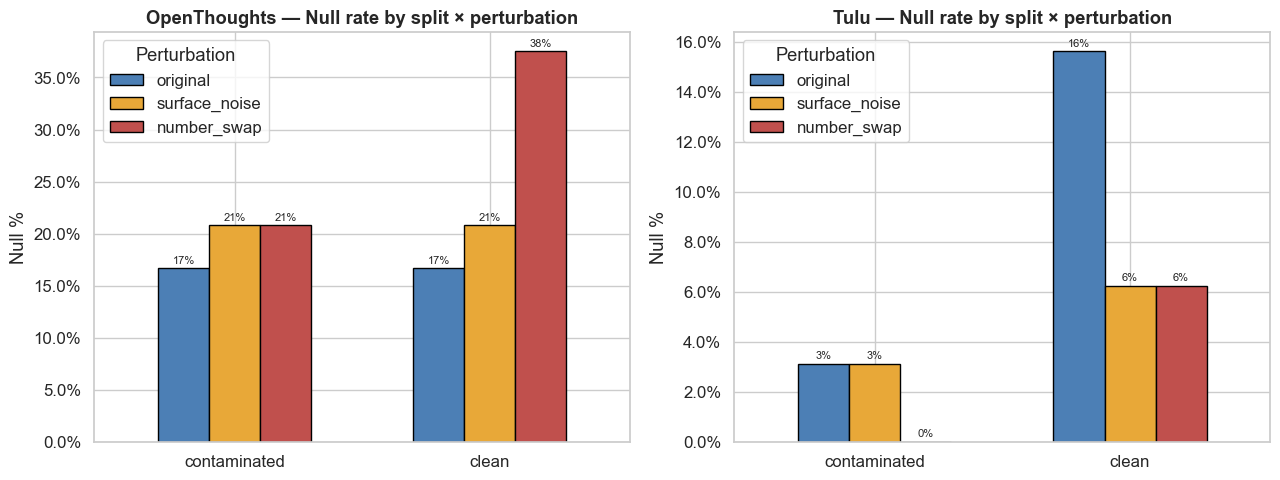

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
ptype_order = ['original', 'surface_noise', 'number_swap']

for ax, (label, paths) in zip(axes, FILES.items()):
    sub = null_rate_df[null_rate_df['Model'] == label]
    pivot = sub.pivot_table(index='split', columns='perturbation_type', values='null_pct')[ptype_order]
    pivot.plot(kind='bar', ax=ax, color=['#4c7fb5', '#e8a838', '#c0504d'],
               edgecolor='black', width=0.6)
    ax.set_title(f'{label} — Null rate by split × perturbation', fontweight='bold')
    ax.set_ylabel('Null %')
    ax.set_xlabel('')
    ax.set_xticklabels(['contaminated', 'clean'], rotation=0)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Perturbation')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('fig_null_rates.png', dpi=150)
plt.show()

## 8. Chain-of-Thought Analysis

Extract CoT features per trace: word count, uncertainty markers, hedging, self-correction, math density, TTR.

In [13]:
UNCERTAINTY = [
    r'\bno wait\b', r'\bwait,?\s+no\b', r'\bhold on\b',
    r'\blet me reconsider\b', r'\blet me re-?think\b', r'\blet me redo\b',
    r'\bstep back\b', r'\bi made an error\b',
    r"\bthat('s| is) (wrong|incorrect|not right)\b",
    r"\bwait,?\s+that'?s?\s+(wrong|not right|incorrect)\b",
]
HEDGING = [
    r"\bi'?m not sure\b", r"\bi'?m not certain\b", r'\bnot certain\b',
    r'\bi believe\b', r'\bseems like\b', r'\bseems to be\b', r'\bprobably\b',
    r'\bperhaps\b', r'\bi think (that )?this\b',
    r'\bif i recall\b', r'\bif i remember\b',
]
SELF_CORRECT = [
    r'\bactually,?\s+(no|wait|let me)\b', r'\bno,?\s+wait\b',
    r'\blet me recalculate\b', r'\blet me re-?do\b', r'\bi was wrong\b',
    r'\bi (made a |have a )?mistake\b', r'\bthat was (a )?mistake\b',
    r'\blet me correct\b', r'\bi need to correct\b',
    r'\bmy (previous |earlier )?calculation was (wrong|incorrect|off)\b',
]

def count_patterns(text, patterns):
    return sum(len(re.findall(p, text, re.IGNORECASE)) for p in patterns)

def extract_cot_features(r):
    trace = r.get('full_trace')
    if not trace:
        return None
    text = re.sub(r'<\|.*?\|>', '', trace).strip()
    words = text.split()
    clean_words = [w.strip(string.punctuation).lower() for w in words if w.strip(string.punctuation)]
    math_tokens = len(re.findall(r'\d+\.?\d*|[+\-*/=^√∫∑]|\\[a-zA-Z]+', text))
    return {
        'model': r.get('model'), 'split': r.get('split'),
        'perturbation_type': r.get('perturbation_type'),
        'llm_correct': r.get('llm_correct'),
        'word_count': len(words),
        'uncertainty': count_patterns(text, UNCERTAINTY),
        'hedging': count_patterns(text, HEDGING),
        'self_correction': count_patterns(text, SELF_CORRECT),
        'math_density': math_tokens / max(len(words), 1),
        'ttr': len(set(clean_words)) / max(len(clean_words), 1),
    }

cot_rows = []
for label, paths in FILES.items():
    for r in load_jsonl(paths['combined']):
        feat = extract_cot_features(r)
        if feat:
            feat['Model'] = label
            cot_rows.append(feat)

cot_df = pd.DataFrame(cot_rows)

# Summary table: model x split x perturbation
metrics = ['word_count','uncertainty','hedging','self_correction','math_density','ttr']
cot_summary = cot_df.groupby(['Model','split','perturbation_type'])[metrics].mean().round(3)
print(cot_summary.to_string())

                                             word_count  uncertainty  hedging  self_correction  math_density    ttr
Model        split        perturbation_type                                                                        
OpenThoughts clean        number_swap          1465.083        2.292    1.917            0.417         0.426  0.255
                          original             1251.333        2.000    1.167            0.375         0.378  0.263
                          surface_noise        1313.417        1.750    1.875            0.292         0.397  0.265
             contaminated number_swap          1438.750        1.333    1.583            0.375         0.442  0.263
                          original             1159.583        1.333    0.667            0.167         0.452  0.284
                          surface_noise        1276.875        1.500    1.250            0.167         0.415  0.277
Tulu         clean        number_swap           275.375        0.000    

/var/folders/c5/r0s3ndh947q37zmscpdw74880000gq/T/ipykernel_46002/1549047060.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([clean_vals, contam_vals], labels=['clean', 'contaminated'],
/var/folders/c5/r0s3ndh947q37zmscpdw74880000gq/T/ipykernel_46002/1549047060.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([clean_vals, contam_vals], labels=['clean', 'contaminated'],
/var/folders/c5/r0s3ndh947q37zmscpdw74880000gq/T/ipykernel_46002/1549047060.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([clean_vals, contam_vals], labels=['clean', 'contaminated'],
/var/folders/c5/r0s3nd

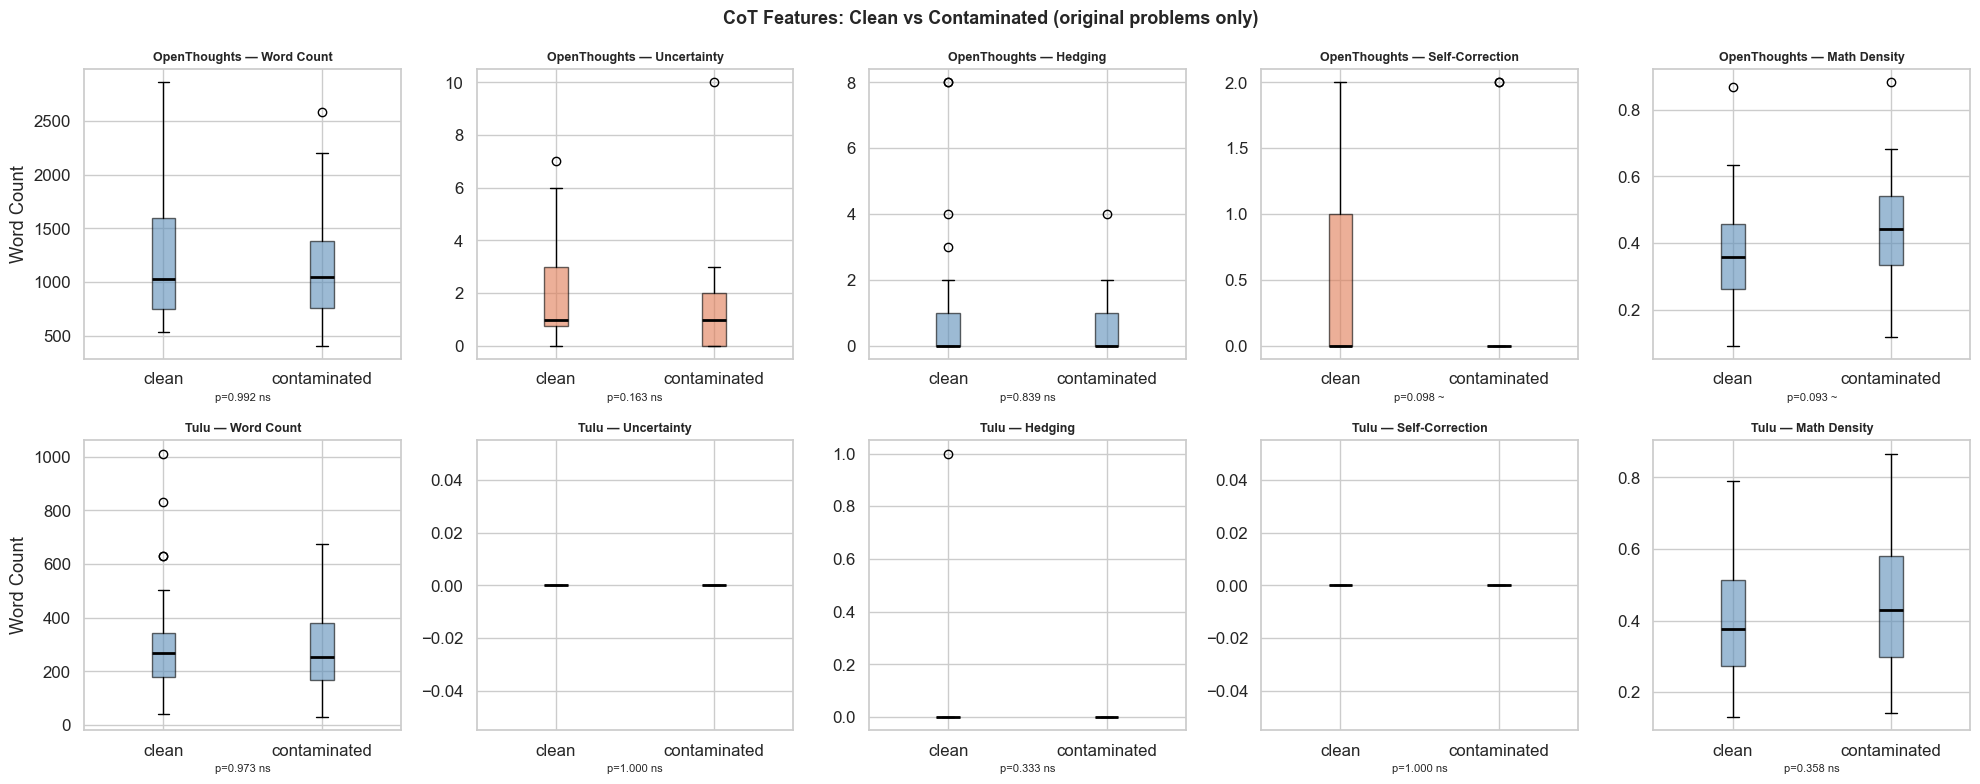

In [20]:
# CoT feature comparison: clean vs contaminated on original problems
orig_cot = cot_df[cot_df['perturbation_type'] == 'original']
plot_metrics = ['word_count', 'uncertainty', 'hedging', 'self_correction', 'math_density']
metric_labels = ['Word Count', 'Uncertainty', 'Hedging', 'Self-Correction', 'Math Density']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for row, (label, paths) in enumerate(FILES.items()):
    sub = orig_cot[orig_cot['Model'] == label]
    for col, (metric, mlabel) in enumerate(zip(plot_metrics, metric_labels)):
        ax = axes[row][col]
        clean_vals  = sub[sub['split'] == 'clean'][metric].dropna()
        contam_vals = sub[sub['split'] == 'contaminated'][metric].dropna()
        ax.boxplot([clean_vals, contam_vals], labels=['clean', 'contaminated'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#5b8db8' if col % 2 == 0 else '#e07b54', alpha=0.6),
                   medianprops=dict(color='black', linewidth=2))
        ax.set_title(f'{label} — {mlabel}', fontsize=9, fontweight='bold')
        ax.set_ylabel(mlabel if col == 0 else '')
        u, p = stats.mannwhitneyu(clean_vals, contam_vals, alternative='two-sided')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ('~' if p < 0.10 else 'ns')))
        ax.set_xlabel(f'p={p:.3f} {sig}', fontsize=8)

plt.suptitle('CoT Features: Clean vs Contaminated (original problems only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cot_features.png', dpi=150)
plt.show()

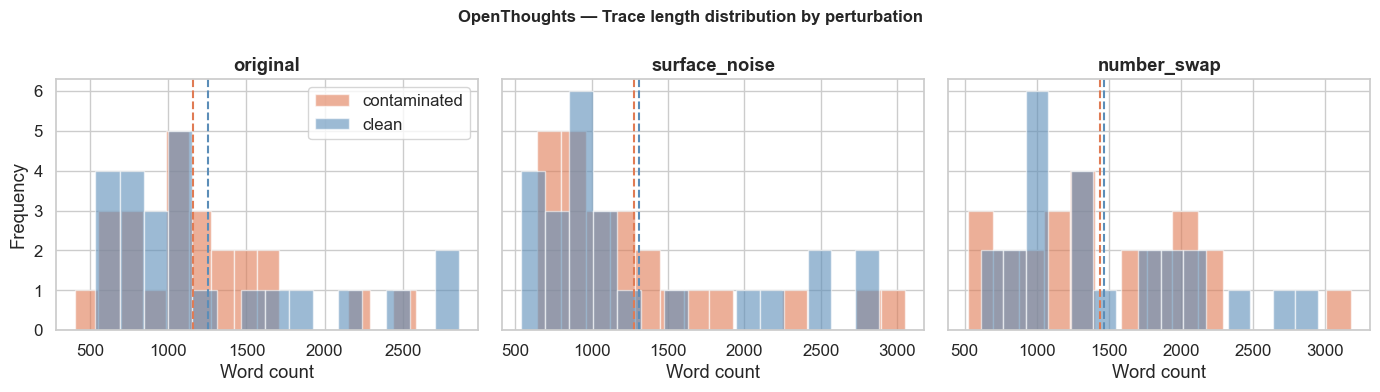

In [15]:
# Word count distribution by perturbation type (OpenThoughts only — Tulu too terse)
ot_cot = cot_df[cot_df['Model'] == 'OpenThoughts']

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ptype in zip(axes, ['original', 'surface_noise', 'number_swap']):
    sub = ot_cot[ot_cot['perturbation_type'] == ptype]
    for split, color in PALETTE.items():
        vals = sub[sub['split'] == split]['word_count'].dropna()
        ax.hist(vals, bins=15, alpha=0.6, color=color, label=split, edgecolor='white')
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(ptype, fontweight='bold')
    ax.set_xlabel('Word count')
    if ax == axes[0]:
        ax.set_ylabel('Frequency')
        ax.legend()

fig.suptitle('OpenThoughts — Trace length distribution by perturbation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_trace_length.png', dpi=150)
plt.show()

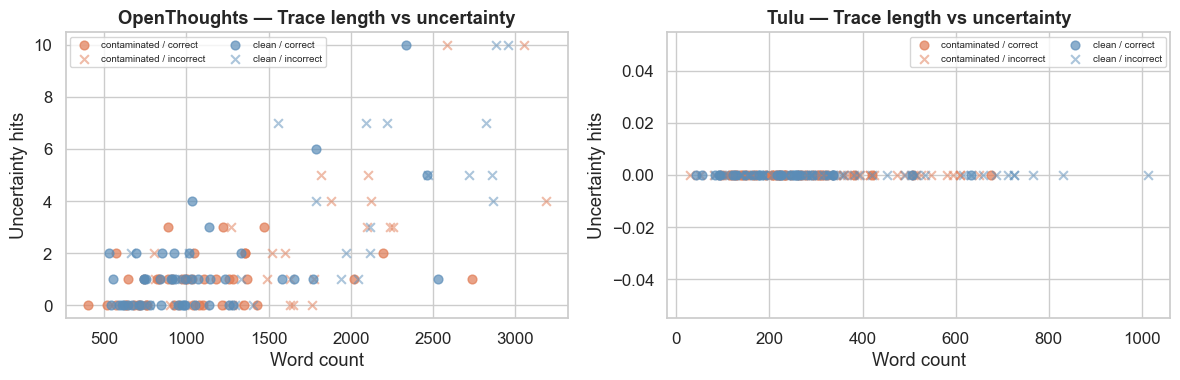

In [16]:
# Correctness vs trace length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, paths) in zip(axes, FILES.items()):
    sub = cot_df[cot_df['Model'] == label].dropna(subset=['llm_correct'])
    for split, color in PALETTE.items():
        for correct, marker, alpha in [(True, 'o', 0.7), (False, 'x', 0.5)]:
            vals = sub[(sub['split'] == split) & (sub['llm_correct'] == correct)]
            ax.scatter(vals['word_count'], vals['uncertainty'],
                       color=color, marker=marker, alpha=alpha, s=40,
                       label=f'{split} / {"correct" if correct else "incorrect"}')
    ax.set_title(f'{label} — Trace length vs uncertainty', fontweight='bold')
    ax.set_xlabel('Word count')
    ax.set_ylabel('Uncertainty hits')
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('fig_length_vs_uncertainty.png', dpi=150)
plt.show()

## 9. Mann-Whitney U Tests: CoT Features (Clean vs Contaminated on Original Problems)

In [17]:
mwu_rows = []
orig_cot = cot_df[cot_df['perturbation_type'] == 'original']

for label in FILES:
    sub = orig_cot[orig_cot['Model'] == label]
    clean_sub  = sub[sub['split'] == 'clean']
    contam_sub = sub[sub['split'] == 'contaminated']
    for metric in ['word_count','uncertainty','hedging','self_correction','math_density']:
        a = clean_sub[metric].dropna().values
        b = contam_sub[metric].dropna().values
        if len(a) < 2 or len(b) < 2:
            continue
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        pooled_std = np.std(np.concatenate([a, b])) + 1e-9
        d = (a.mean() - b.mean()) / pooled_std
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ('~' if p < 0.10 else 'ns')))
        mwu_rows.append({'Model': label, 'Metric': metric,
                         'Clean mean': round(a.mean(), 3), 'Contam mean': round(b.mean(), 3),
                         'U': u, 'p': round(p, 4), 'sig': sig, "Cohen's d": round(d, 2)})

mwu_df = pd.DataFrame(mwu_rows)
print(mwu_df.to_string(index=False))

       Model          Metric  Clean mean  Contam mean     U      p sig  Cohen's d
OpenThoughts      word_count    1251.333     1159.583 287.0 0.9918  ns       0.15
OpenThoughts     uncertainty       2.000        1.333 354.0 0.1628  ns       0.32
OpenThoughts         hedging       1.167        0.667 279.0 0.8395  ns       0.28
OpenThoughts self_correction       0.375        0.167 343.0 0.0983   ~       0.35
OpenThoughts    math_density       0.378        0.452 206.0 0.0929   ~      -0.44
        Tulu      word_count     308.656      292.938 509.0 0.9732  ns       0.08
        Tulu     uncertainty       0.000        0.000 512.0 1.0000  ns       0.00
        Tulu         hedging       0.031        0.000 528.0 0.3327  ns       0.25
        Tulu self_correction       0.000        0.000 512.0 1.0000  ns       0.00
        Tulu    math_density       0.399        0.446 443.0 0.3577  ns      -0.26


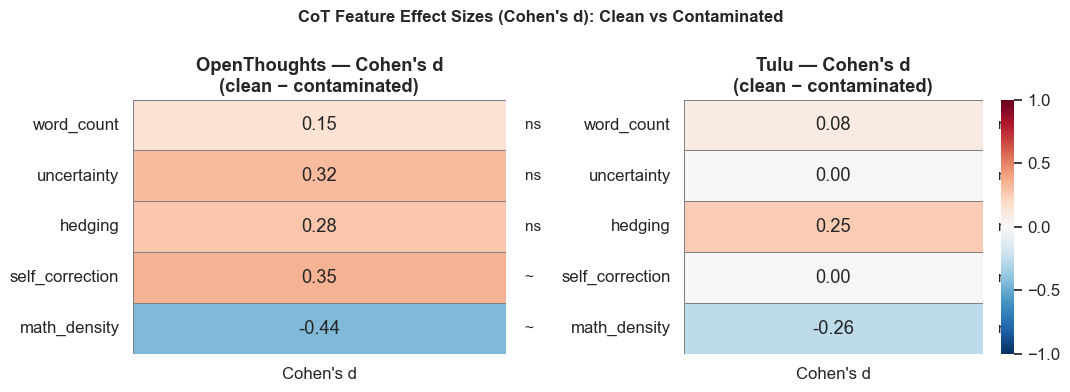

In [18]:
# Cohen's d heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, label in zip(axes, FILES):
    sub = mwu_df[mwu_df['Model'] == label].set_index('Metric')["Cohen's d"].to_frame()
    sns.heatmap(sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, cbar=ax == axes[-1],
                linewidths=0.5, linecolor='grey')
    ax.set_title(f"{label} — Cohen's d\n(clean − contaminated)", fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    for i, row in enumerate(mwu_df[mwu_df['Model'] == label].itertuples()):
        ax.text(1.05, i + 0.5, row.sig, transform=ax.transData, fontsize=11,
                va='center', ha='left')

plt.suptitle("CoT Feature Effect Sizes (Cohen's d): Clean vs Contaminated", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cohens_d_heatmap.png', dpi=150)
plt.show()

## 10. Summary: CoT Features by Correctness

                                       word_count  uncertainty  hedging  self_correction
Model        split        llm_correct                                                   
OpenThoughts clean        False           1837.88         3.38     3.35             0.69
                          True            1063.72         1.24     0.70             0.17
             contaminated False           1640.38         2.21     2.03             0.38
                          True            1056.60         0.84     0.58             0.14
Tulu         clean        False            320.72         0.00     0.01             0.00
                          True             228.05         0.00     0.00             0.00
             contaminated False            281.65         0.00     0.00             0.00
                          True             257.18         0.00     0.00             0.00


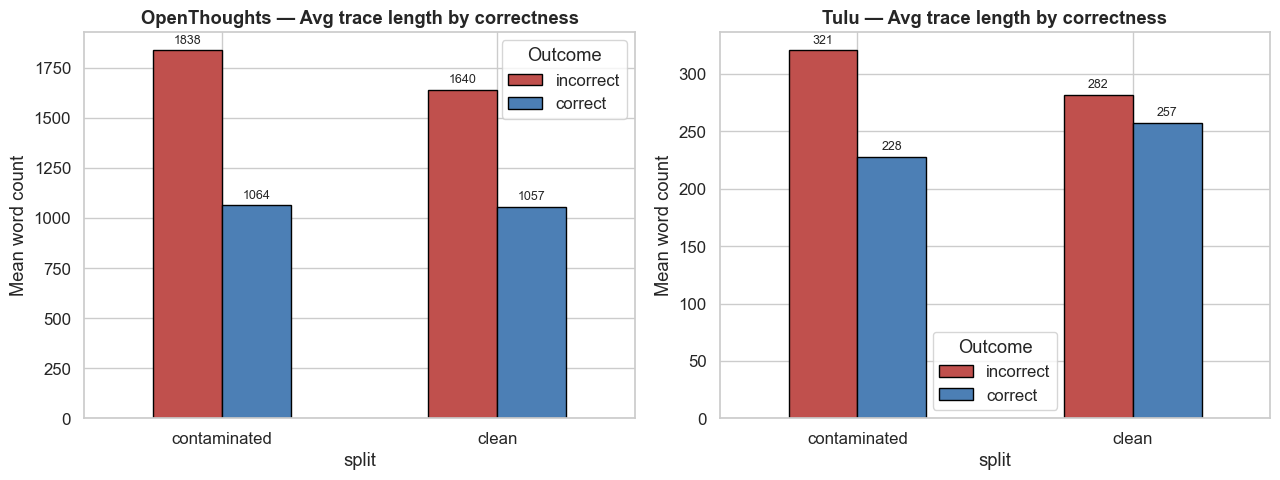

All figures saved.


In [19]:
correctness_summary = (cot_df.dropna(subset=['llm_correct'])
                        .groupby(['Model', 'split', 'llm_correct'])
                        [['word_count','uncertainty','hedging','self_correction']]
                        .mean().round(2))
print(correctness_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, paths) in zip(axes, FILES.items()):
    sub = (cot_df[(cot_df['Model'] == label)]
           .dropna(subset=['llm_correct'])
           .groupby(['split', 'llm_correct'])['word_count']
           .mean().unstack())
    sub.columns = ['incorrect', 'correct']
    sub.plot(kind='bar', ax=ax, color=['#c0504d', '#4c7fb5'], edgecolor='black', width=0.5)
    ax.set_title(f'{label} — Avg trace length by correctness', fontweight='bold')
    ax.set_ylabel('Mean word count')
    ax.set_xticklabels(['contaminated', 'clean'], rotation=0)
    ax.legend(title='Outcome')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('fig_length_by_correctness.png', dpi=150)
plt.show()
print('All figures saved.')